<a href="https://colab.research.google.com/github/SKSAHILAKHTAR1/AI-Powered-SDR-Laboratory/blob/main/Matched_filter_and_eye_diagram.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

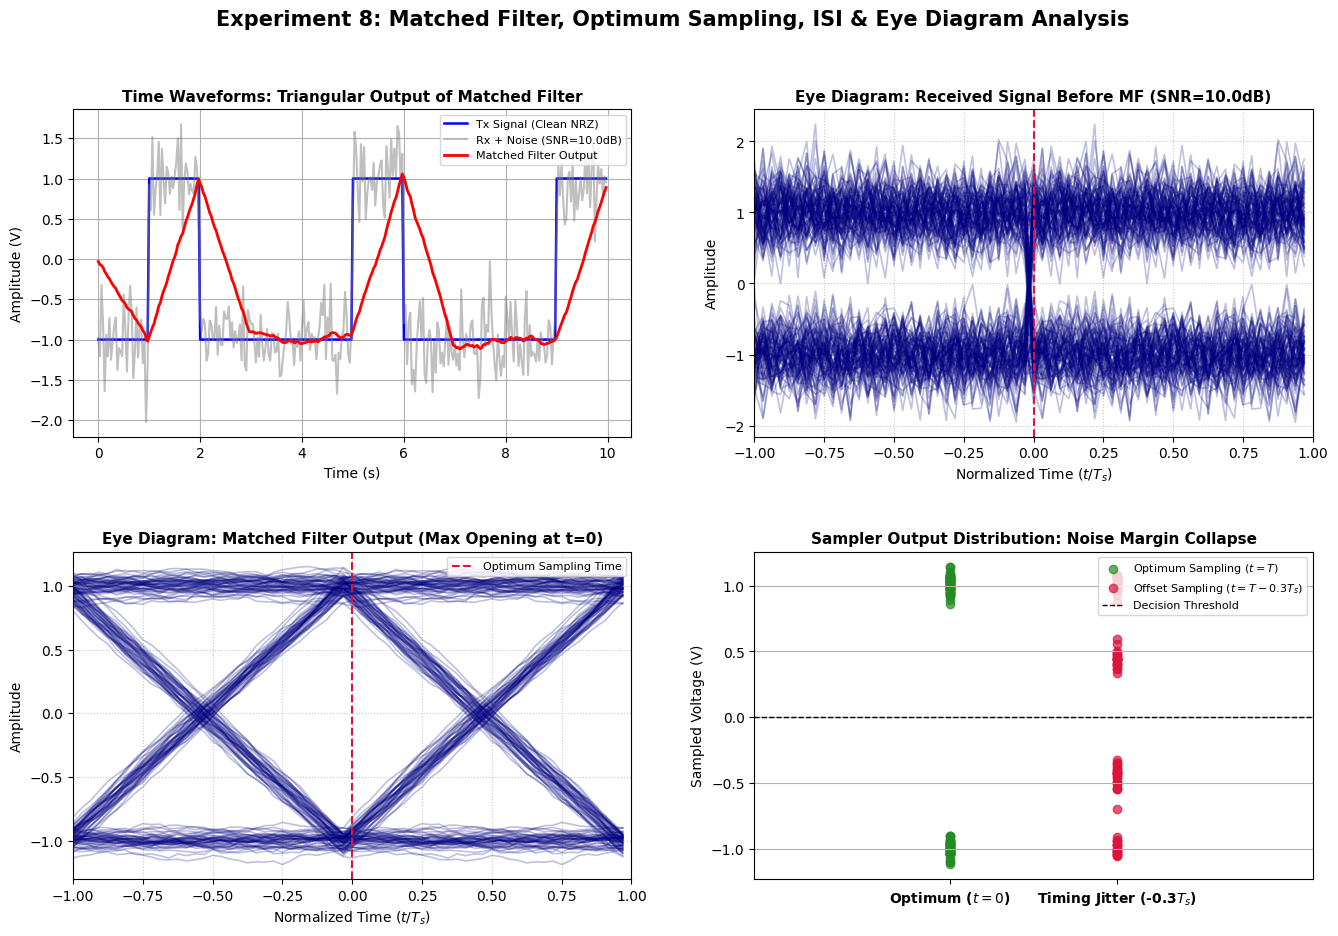

Mean Separation at Optimum Sampling : 2.0003 V
Mean Separation with 30% Timing Error : 1.4176 V


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ====================================================================
# 1. SIMULATION PARAMETERS & SIGNAL GENERATION
# ====================================================================
np.random.seed(42)
N_symbols = 600           # Number of transmitted symbols
sps = 32                  # Samples per symbol (oversampling factor)
Ts = 1.0                  # Symbol duration (seconds)
fs = sps / Ts             # Sampling rate (Hz)

# Generate random bipolar symbols: a_k in {-1, +1}
symbols = 2 * np.random.randint(0, 2, N_symbols) - 1

# Transmitted pulse: Rectangular NRZ pulse of duration Ts
pulse = np.ones(sps)

# Modulated signal: Upsample symbols and convolve with rectangular pulse
upsampled = np.zeros(N_symbols * sps)
upsampled[::sps] = symbols
tx_signal = np.convolve(upsampled, pulse, mode='full')[:N_symbols * sps]

# ====================================================================
# 2. AWGN CHANNEL & MATCHED FILTERING
# ====================================================================
# Add AWGN with target SNR
snr_db = 10.0
sig_power = np.mean(tx_signal ** 2)
noise_power = sig_power / (10 ** (snr_db / 10.0))
noise = np.random.normal(0, np.sqrt(noise_power), len(tx_signal))
rx_signal = tx_signal + noise

# Matched Filter for rectangular pulse: h(t) = p(T - t) = p(t)
# Filter impulse response normalized to unit energy
h_mf = pulse[::-1] / sps
mf_output = np.convolve(rx_signal, h_mf, mode='full')[:len(rx_signal)]

# ====================================================================
# 3. OPTIMUM VS TIMING ERROR SAMPLER OUTPUT
# ====================================================================
# Optimum sampling occurs at group delay / peak point of each symbol
opt_sample_idx = sps - 1
opt_samples = mf_output[opt_sample_idx::sps]

# Timing error sampling (e.g., 30% symbol clock delay jitter)
timing_offset = int(0.30 * sps)
jittered_sample_idx = opt_sample_idx - timing_offset
jittered_samples = mf_output[jittered_sample_idx::sps]

# ====================================================================
# 4. EYE DIAGRAM EXTRACTOR FUNCTION
# ====================================================================
def plot_eye_diagram(ax, signal, sps, num_traces=150, title="Eye Diagram"):
    """
    Overlays segments of length 2 * sps to produce a 2-symbol eye diagram.
    """
    trace_len = 2 * sps
    t_eye = np.linspace(-1.0, 1.0, trace_len, endpoint=False)

    # Discard initial transient (first 10 symbols)
    start_offset = 10 * sps
    for i in range(num_traces):
        idx = start_offset + i * sps
        if idx + trace_len <= len(signal):
            ax.plot(t_eye, signal[idx:idx + trace_len], color='navy', alpha=0.25, lw=1.2)

    ax.axvline(0.0, color='crimson', linestyle='--', lw=1.5, label='Optimum Sampling Time')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel(r"Normalized Time ($t / T_s$)")
    ax.set_ylabel("Amplitude")
    ax.set_xlim(-1.0, 1.0)
    ax.grid(True, linestyle=':', alpha=0.7)

# ====================================================================
# 5. COMPREHENSIVE 4-PANEL VISUALIZATION
# ====================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
plt.subplots_adjust(hspace=0.35, wspace=0.22)
fig.suptitle("Experiment 8: Matched Filter, Optimum Sampling, ISI & Eye Diagram Analysis", fontsize=15, fontweight='bold')

# Plot 1: Waveforms Comparison (Tx, Noisy Rx, Matched Filter Output)
t_disp = np.arange(0, 10 * sps) / fs
axes[0, 0].plot(t_disp, tx_signal[:10 * sps], 'b-', lw=1.8, label="Tx Signal (Clean NRZ)")
axes[0, 0].plot(t_disp, rx_signal[:10 * sps], 'gray', alpha=0.5, label=f"Rx + Noise (SNR={snr_db}dB)")
axes[0, 0].plot(t_disp, mf_output[:10 * sps], 'r-', lw=2.0, label="Matched Filter Output")
axes[0, 0].set_title("Time Waveforms: Triangular Output of Matched Filter", fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel("Time (s)")
axes[0, 0].set_ylabel("Amplitude (V)")
axes[0, 0].grid(True)
axes[0, 0].legend(loc='upper right', fontsize=8)

# Plot 2: Eye Diagram of Raw Received Signal (Before Matched Filtering)
plot_eye_diagram(axes[0, 1], rx_signal, sps, num_traces=180, title=f"Eye Diagram: Received Signal Before MF (SNR={snr_db}dB)")

# Plot 3: Eye Diagram of Matched Filter Output (After MF)
plot_eye_diagram(axes[1, 0], mf_output, sps, num_traces=180, title="Eye Diagram: Matched Filter Output (Max Opening at t=0)")
axes[1, 0].legend(loc='upper right', fontsize=8)

# Plot 4: Discrete Sampler Scatter / Histogram (Optimum vs Timing Error)
axes[1, 1].scatter(np.zeros_like(opt_samples[:100]) - 0.15, opt_samples[:100], color='forestgreen', alpha=0.7, label='Optimum Sampling ($t=T$)')
axes[1, 1].scatter(np.zeros_like(jittered_samples[:100]) + 0.15, jittered_samples[:100], color='crimson', alpha=0.7, label=rf'Offset Sampling ($t=T - 0.3T_s$)')
axes[1, 1].axhline(0.0, color='black', linestyle='--', lw=1.0, label='Decision Threshold')
axes[1, 1].set_title("Sampler Output Distribution: Noise Margin Collapse", fontsize=11, fontweight='bold')
axes[1, 1].set_xticks([-0.15, 0.15])
axes[1, 1].set_xticklabels(['Optimum ($t=0$)', rf'Timing Jitter (-0.3$T_s$)'], fontweight='bold')
axes[1, 1].set_ylabel("Sampled Voltage (V)")
axes[1, 1].set_xlim(-0.5, 0.5)
axes[1, 1].grid(True, axis='y')
axes[1, 1].legend(loc='upper right', fontsize=8)

plt.show()

# Verification Metric Printout
print(f"Mean Separation at Optimum Sampling : {np.abs(np.mean(opt_samples[symbols == 1]) - np.mean(opt_samples[symbols == -1])):.4f} V")
print(f"Mean Separation with 30% Timing Error : {np.abs(np.mean(jittered_samples[symbols == 1]) - np.mean(jittered_samples[symbols == -1])):.4f} V")